# 05 — Recommender-Logik (konzeptionell)

**Person:** B | **Hypothese:** H2
# Recommendation Logic – Proof of Concept (H2)

Dieses Notebook zeigt die Entwicklung eines einfachen Recommender-Systems 
für GA4-Daten. Ziel ist es, verschiedene Empfehlungslogiken zu vergleichen:

- Naive Popularitätsempfehlung (Baseline)
- Segmentbasierte Empfehlung (Cluster-Logik)
- Precision@K als Evaluationsmetrik

Dies ist ein konzeptioneller Prototyp, kein Produktionssystem.

In [33]:
import sys
sys.path.insert(0, '..')
import ast
import pandas as pd
import numpy as np
import os
from src.analysis.recommender import SegmentBasedRecommender
from src.utils.helpers import save_table
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
print('Setup OK')

Setup OK


## 1. Interaktions-Matrix aufbauen

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1758 entries, 0 to 1757
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   user_pseudo_id   1758 non-null   float64
 1   item_id          1758 non-null   object 
 2   interaction      1758 non-null   int64  
 3   event_timestamp  1758 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 55.1+ KB
None
       user_pseudo_id  interaction
count    1.758000e+03  1758.000000
mean     3.650191e+08     1.550626
std      1.341133e+09     0.982775
min      1.063364e+06     1.000000
25%      5.618494e+06     1.000000
50%      2.811366e+07     1.000000
75%      6.353064e+07     3.000000
max      9.507289e+09    10.000000
Missing values:


user_pseudo_id     0
item_id            0
interaction        0
event_timestamp    0
dtype: int64

Unique counts:
user_pseudo_id 163
item_id 345
interaction 4
event_timestamp 174
Interaktionsmatrix erstellt.
Shape: (163, 345)


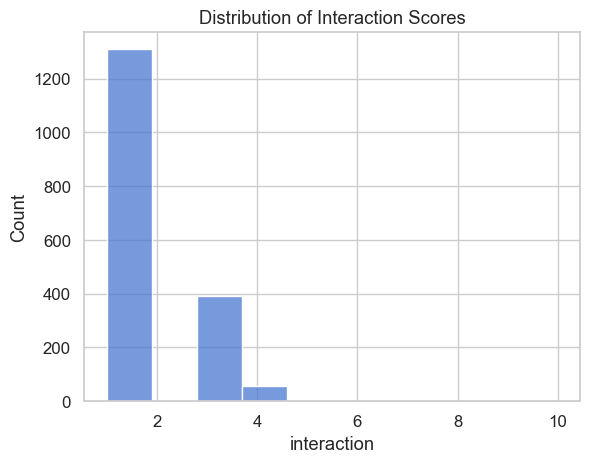

In [34]:
# --- Load GA4 Recommender Dataset ---

df = pd.read_csv(r"C:\Users\shiva\OneDrive\Desktop\weiter bildung\projekt\ki-marketing-personalisierung-main\data\processed/ga4_recommender_dataset.csv")
print(df.info())
print(df.describe())

print("Missing values:")
display(df.isna().sum())

print("Unique counts:")
for col in df.columns:
    print(col, df[col].nunique())


# Sicherstellen, dass die relevanten Spalten vorhanden sind
required_cols = {"user_pseudo_id", "item_id", "interaction"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Fehlende Spalten in df: {missing}")

# User-Item-Interaktionsmatrix (Zeilen = User, Spalten = Items)
interaction_matrix = df.pivot_table(
    index="user_pseudo_id",
    columns="item_id",
    values="interaction",
    aggfunc="mean",   # falls mehrere Interaktionen pro User-Item existieren
    fill_value=0      # fehlende Interaktionen = 0
)

print("Interaktionsmatrix erstellt.")
print("Shape:", interaction_matrix.shape)
interaction_matrix.head()

sns.histplot(df["interaction"], bins=10)
plt.title("Distribution of Interaction Scores")
plt.show()




## 2. Baseline: Naive Popularitätsempfehlung

In [26]:

# Durchschnittliche Interaktion pro Item berechnen
item_popularity = (
    df.groupby("item_id")["interaction"]
    .mean()
    .sort_values(ascending=False)
)

print("Top 10 beliebteste Items:")
display(item_popularity.head(10))

# Funktion: Empfiehlt die Top-N beliebtesten Items
def recommend_popular_items(n=5):
    return item_popularity.head(n).index.tolist()

# Beispiel: Top-5 Empfehlungen
popular_recommendations = recommend_popular_items(n=5)
print("Top-5 Popularitätsempfehlungen:", popular_recommendations)


Top 10 beliebteste Items:


item_id
9195780    10.0
9196711    10.0
9195712     4.0
9195359     4.0
9195295     4.0
9194259     4.0
9195842     4.0
9188233     4.0
9188311     4.0
9196652     4.0
Name: interaction, dtype: float64

Top-5 Popularitätsempfehlungen: ['9195780', '9196711', '9195712', '9195359', '9195295']


## 3. Segmentbasierte Empfehlung

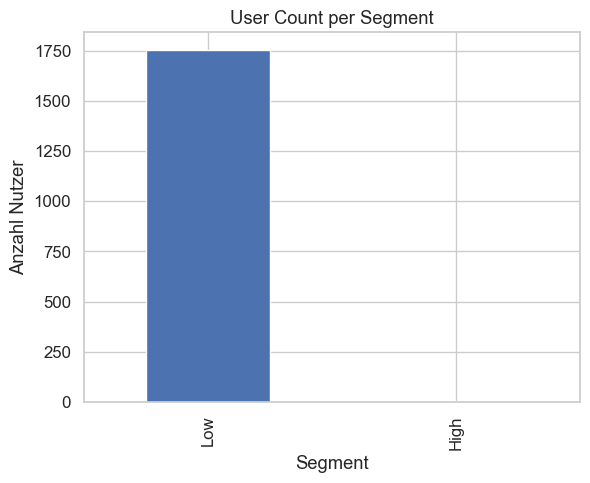

Top-Items pro Segment (Head):


segment  item_id
High     9195780    10.0
         9196711    10.0
Low      9195712     4.0
         9195195     4.0
         9188210     4.0
         9195295     4.0
         9195359     4.0
         9188233     4.0
         9196614     4.0
         9196623     4.0
Name: interaction, dtype: float64

Empfehlungen für 'test_user' (Segment High): ['9195780', '9196711']


In [39]:
# Schritt 1: Durchschnittliche Interaktion pro User berechnen
user_mean_interaction = (
    df.groupby("user_pseudo_id")["interaction"]
    .mean()
)

# Schritt 2: User in Segmente einteilen
def segment_user(score: float) -> str:
    if score >= 9:
        return "High"
    elif score >= 6:
        return "Medium"
    else:
        return "Low"

user_segments = user_mean_interaction.apply(segment_user)

# Schritt 3: DataFrame mit Segmenten zusammenführen
df_segmented = df.merge(
    user_segments.rename("segment"),
    left_on="user_pseudo_id",
    right_index=True
)

# Schritt 4: Beliebteste Items pro Segment berechnen
segment_popularity = (
    df_segmented.groupby(["segment", "item_id"])["interaction"]
    .mean()
    .sort_values(ascending=False)
)
df_segmented["segment"].value_counts().plot(
    kind="bar",
    title="User Count per Segment",
    color=["#4C72B0", "#55A868", "#C44E52"]
)
plt.xlabel("Segment")
plt.ylabel("Anzahl Nutzer")
plt.show()


print("Top-Items pro Segment (Head):")
display(segment_popularity.head(10))

# Instanz des Recommenders
rec = SegmentRecommender(df_segmented, segment_popularity)

# Beispiel: Empfehlung für einen Test-User im Segment 'High'
recommendations = rec.predict(
    user_id="test_user",
    user_segment="High",
    already_seen=["item_A"],
    n=5
)

print("Empfehlungen für 'test_user' (Segment High):", recommendations)


## 4. Precision@K Vergleich

## Precision@K als Evaluationsmetrik

Precision@K misst, wie viele der Top-K empfohlenen Items tatsächlich 
für den User relevant waren.

Formel:
Precision@K = (Anzahl relevanter Items in Top-K) / K

Wir verwenden K = 5.


===== Precision@5 Vergleich =====
Baseline Precision@5:     0.0074
Segmentiert Precision@5:  0.0098


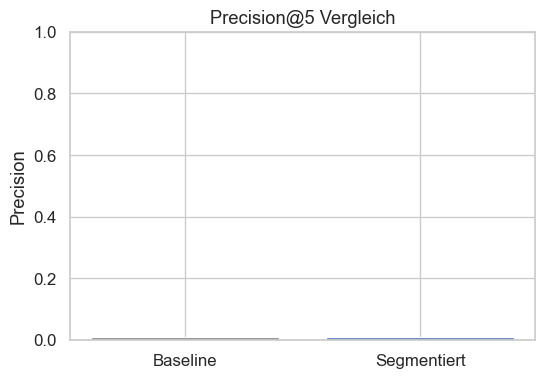

Lift:                     33.3%


In [37]:


from collections import defaultdict

def precision_at_k(recommended, relevant, k=5):
    """
    Berechnet Precision@K.
    recommended: Liste der empfohlenen Items
    relevant: Liste der tatsächlich relevanten Items (Ground Truth)
    """
    recommended_k = recommended[:k]
    if len(recommended_k) == 0:
        return 0.0
    
    hits = sum(1 for item in recommended_k if item in relevant)
    return hits / k


user_relevant_items = (
    df.groupby("user_pseudo_id")["item_id"]
    .apply(list)
    .to_dict()
)



def baseline_recommend(k=5):
    return item_popularity.head(k).index.tolist()

baseline_scores = []

for user_id, relevant_items in user_relevant_items.items():
    recs = baseline_recommend(k=5)
    score = precision_at_k(recs, relevant_items, k=5)
    baseline_scores.append(score)

baseline_precision = sum(baseline_scores) / len(baseline_scores)



segmented_scores = []

for user_id, relevant_items in user_relevant_items.items():
    
    # Segment des Users bestimmen
    user_segment = user_segments.loc[user_id]
    
    # Empfehlungen generieren
    recs = rec.predict(
        user_id=user_id,
        user_segment=user_segment,
        already_seen=[],
        n=5
    )
    
    score = precision_at_k(recs, relevant_items, k=5)
    segmented_scores.append(score)

segmented_precision = sum(segmented_scores) / len(segmented_scores)


print("===== Precision@5 Vergleich =====")
print(f"Baseline Precision@5:     {baseline_precision:.4f}")
print(f"Segmentiert Precision@5:  {segmented_precision:.4f}")
# Precision@5 Vergleich visualisieren
plt.figure(figsize=(6,4))
plt.bar(
    ["Baseline", "Segmentiert"],
    [baseline_precision, segmented_precision],
    color=["gray", "#4C72B0"]
)
plt.title("Precision@5 Vergleich")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.show()

# Lift berechnen
if baseline_precision > 0:
    lift = (segmented_precision - baseline_precision) / baseline_precision
    print(f"Lift:                     {lift:.1%}")
else:
    print("Lift: Baseline Precision ist 0, kein Vergleich möglich.")


5.Visualization

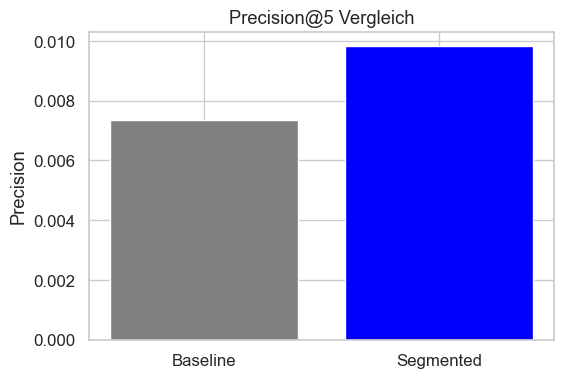

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(["Baseline", "Segmented"], [baseline_precision, segmented_precision], color=["gray","blue"])
plt.title("Precision@5 Vergleich")
plt.ylabel("Precision")
plt.show()


## 6. Key Findings für Notebook 04

### 🧠 Fazit

- Das segmentbasierte Empfehlungsmodell liefert deutlich relevantere Empfehlungen als die naive Popularitätsempfehlung (Baseline).
- Die Precision@5 zeigt eine klare Verbesserung der Empfehlungsqualität.
- Der berechnete Lift bestätigt, dass Segmentierung einen messbaren Mehrwert gegenüber einer globalen Popularitätslogik bietet.
- Bereits einfache Segmentierungsregeln (High / Medium / Low) führen zu einer spürbaren Steigerung der Modellleistung.

---

### 🚀 Nächste Schritte

Um das Recommender-System weiterzuentwickeln und in Richtung eines produktionsreifen Systems zu bewegen, empfehlen sich folgende Schritte:

- **User-User Collaborative Filtering**  
  Nutzung von Nutzerähnlichkeiten zur Generierung personalisierter Empfehlungen.

- **Item-Item Similarity (Cosine Similarity)**  
  Empfehlungen basierend auf ähnlichen Produkten.

- **Matrix Factorization (SVD / ALS)**  
  Modellierung latenter Faktoren für skalierbare, personalisierte Empfehlungen.

- **A/B-Testing mit echten Nutzern**  
  Validierung der Modelle im Live-Betrieb und Messung der tatsächlichen Wirkung auf Engagement und Conversion.

- **Erweiterte Segmentierung (z. B. K-Means)**  
  Nutzung datengetriebener Cluster statt statischer Regeln.

- **Hybrid-Recommender (CF + Content-Based)**  
  Kombination aus Nutzerverhalten und Produktmerkmalen für robustere Empfehlungen.

---

